## Импорт библиотек

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, Birch, HDBSCAN
from sklearn.metrics import silhouette_score

from sklearn.manifold import TSNE

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

import shap
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

In [95]:
import warnings

warnings.filterwarnings("ignore")

## Загрузка и первичная обработка данных

In [30]:
class TargetEncoder:

    def __init__(
        self,
        smoothing: float = 0.0
    ) -> None:
        assert 0.0 <= smoothing <= 1.0, "smoothing must be in [0, 1]"
        self.smoothing = smoothing
        self.global_mean_: float = None
        self.encoding_maps_: dict[str, dict] = {}

    def fit(
        self,
        X: pd.DataFrame,
        y: pd.Series,
        columns: list[str]
    ) -> "TargetEncoder":
        self.columns = columns
        self.global_mean_ = y.mean()
        for col in columns:
            cat_means = (
                pd.concat([X[col], y], axis=1)
                .groupby(col)[y.name]
                .mean()
            )
            encoded = (1 - self.smoothing) * cat_means + self.smoothing * self.global_mean_
            self.encoding_maps_[col] = encoded.to_dict()
        return self

    def transform(
        self,
        X: pd.DataFrame
    ) -> pd.DataFrame:
        X = X.copy()
        for col in self.columns:
            X[col] = X[col].map(self.encoding_maps_[col]).fillna(self.global_mean_)
        return X

    def fit_transform(
        self,
        X: pd.DataFrame,
        y: pd.Series,
        columns: list[str]
    ) -> pd.DataFrame:
        return self.fit(X, y, columns).transform(X)


In [ ]:
df_train = pd.read_csv("../dataset/atm_train_split.csv", encoding='utf-8')
df_test = pd.read_csv("../dataset/atm_test_split.csv", encoding='utf-8')

In [40]:
df_train, df_val = train_test_split(
    df_train, 
    test_size=0.2, 
    random_state=RANDOM_SEED
)
df_train.reset_index(drop=True, inplace=True)
df_val.reset_index(drop=True, inplace=True)

In [42]:
cat_cols = ["region", "atm_group"]

encoder = TargetEncoder(smoothing=0.1)
df_train_encoded = encoder.fit_transform(df_train, df_train["target"], columns=cat_cols)

df_val_encoded = encoder.transform(df_val)
df_test_encoded = encoder.transform(df_test)

In [43]:
FEATURE_COLS = [c for c in df_train.columns if c != "target"]

X_train = df_train[FEATURE_COLS].copy()
y_train = df_train["target"]

X_val = df_val[FEATURE_COLS].copy()
y_val = df_val["target"]

X_test = df_test[FEATURE_COLS].copy()
y_test = df_test["target"]

X_train_encoded = df_train_encoded[FEATURE_COLS]
X_val_encoded = df_val_encoded[FEATURE_COLS]
X_test_encoded = df_test_encoded[FEATURE_COLS]

In [44]:
X_train["atm_group"] = X_train["atm_group"].astype(str)
X_val["atm_group"] = X_val["atm_group"].astype(str)
X_test["atm_group"] = X_test["atm_group"].astype(str)

In [45]:
for col in cat_cols:
    X_train[col] = X_train[col].astype("category")
    X_val[col] = X_val[col].astype("category")
    X_test[col] = X_test[col].astype("category")

In [9]:
def test_performance(y_true, y_pred):
    test_rmse = root_mean_squared_error(y_true, y_pred)
    test_mae = mean_absolute_error(y_true, y_pred)
    test_r2 = r2_score(y_true, y_pred)
    
    print(f"\nTest Performance:")
    print(f"   RMSE: {test_rmse:.4f}")
    print(f"   MAE:  {test_mae:.4f}")
    print(f"   R²:   {test_r2:.3f}")

## Решающее дерево

С дефолтными параметрами:

In [46]:
dt = DecisionTreeRegressor(random_state=RANDOM_SEED)
dt.fit(X_train_encoded, y_train)

y_pred = dt.predict(X_test_encoded)

test_performance(y_test, y_pred)


Test Performance:
   RMSE: 0.0592
   MAE:  0.0454
   R²:   0.541


**Промежуточные результаты:** Решающее дерево показало средний результат по сравнению с линейными моделями.

In [47]:
def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 2, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 50),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
        "max_features": trial.suggest_float("max_features", 0.3, 1.0),
        "random_state": RANDOM_SEED,
    }
    model = DecisionTreeRegressor(**params)
    model.fit(X_train_encoded, y_train)
    y_pred = model.predict(X_val_encoded)
    return root_mean_squared_error(y_val, y_pred)


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=200, show_progress_bar=True)

print(f"Best RMSE: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")


Best trial: 27. Best value: 0.0490714: 100%|██████████| 200/200 [00:04<00:00, 44.05it/s]

Best RMSE: 0.0491
Best params: {'max_depth': 5, 'min_samples_split': 50, 'min_samples_leaf': 30, 'max_features': 0.865356991926611}


In [48]:
dt_tuned = DecisionTreeRegressor(**study.best_params, random_state=RANDOM_SEED)
dt_tuned.fit(X_train_encoded, y_train)

y_pred_tuned = dt_tuned.predict(X_test_encoded)
test_performance(y_test, y_pred_tuned)


Test Performance:
   RMSE: 0.0462
   MAE:  0.0372
   R²:   0.721


**Результаты:**
- RMSE: 0.0462
- MAE: 0.0372
- R²: 0.721

**Лучшие параметры:**
- max_depth: 5
- min_samples_split: 50
- min_samples_leaf: 30
- max_features: 0.87

**Вывод:** Решающее дерево показало результат хуже, чем лучший результат линейных моделей (RMSE = 0.0452).

## Случайный лес

In [49]:
rf = RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(X_train_encoded, y_train)

y_pred_rf = rf.predict(X_test_encoded)
test_performance(y_test, y_pred_rf)


Test Performance:
   RMSE: 0.0434
   MAE:  0.0342
   R²:   0.754


**Промежуточные результаты:** Случайный лес показал новый лучший результат, превзойдя все предыдущие модели.

In [52]:
def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 2, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 50),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
        "max_features": trial.suggest_float("max_features", 0.3, 1.0),
        "random_state": RANDOM_SEED,
        "n_jobs": -1,
    }
    model = RandomForestRegressor(**params)
    model.fit(X_train_encoded, y_train)
    y_pred = model.predict(X_val_encoded)
    return root_mean_squared_error(y_val, y_pred)


study_rf = optuna.create_study(direction="minimize")
study_rf.optimize(objective_rf, n_trials=100, show_progress_bar=True)

print(f"Best RMSE: {study_rf.best_value:.4f}")
print(f"Best params: {study_rf.best_params}")

Best trial: 66. Best value: 0.0467924: 100%|██████████| 100/100 [00:45<00:00,  2.20it/s]

Best RMSE: 0.0468
Best params: {'n_estimators': 357, 'max_depth': 26, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 0.4117617376684628}


In [53]:
rf_tuned = RandomForestRegressor(**study_rf.best_params, random_state=RANDOM_SEED, n_jobs=-1)
rf_tuned.fit(X_train_encoded, y_train)

y_pred_rf_tuned = rf_tuned.predict(X_test_encoded)
test_performance(y_test, y_pred_rf_tuned)


Test Performance:
   RMSE: 0.0432
   MAE:  0.0343
   R²:   0.755


**Результаты:**
- RMSE: 0.0432
- MAE: 0.0343
- R²: 0.755

**Лучшие параметры:**
- n_estimators: 357
- max_depth: 26
- min_samples_split: 6
- min_samples_leaf: 2
- max_features: 0.41

**Вывод:** Случайный лес с подобранными гиперпараметрами обновил лучший результат, доведя его до RMSE = 0.0432.

## Бустинг

### CatBoost

In [54]:
cb = CatBoostRegressor(random_seed=RANDOM_SEED, verbose=0)
cb.fit(X_train, y_train, cat_features=cat_cols)

y_pred_cb = cb.predict(X_test)
test_performance(y_test, y_pred_cb)


Test Performance:
   RMSE: 0.0444
   MAE:  0.0352
   R²:   0.742


**Промежуточные результаты:** CatBoost показал результат, который не превзошел случайный лес, но был лучше, чем решающее дерево.

In [55]:
def objective_cb(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 100, 1000),
        "depth": trial.suggest_int("depth", 2, 10),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "random_seed": RANDOM_SEED,
        "verbose": 0,
    }
    model = CatBoostRegressor(**params)
    model.fit(X_train, y_train, cat_features=cat_cols)
    y_pred = model.predict(X_val)
    return root_mean_squared_error(y_val, y_pred)


study_cb = optuna.create_study(direction="minimize")
study_cb.optimize(objective_cb, n_trials=100, show_progress_bar=True)

print(f"Best RMSE: {study_cb.best_value:.4f}")
print(f"Best params: {study_cb.best_params}")

Best trial: 92. Best value: 0.0466974: 100%|██████████| 100/100 [05:19<00:00,  3.19s/it]

Best RMSE: 0.0467
Best params: {'iterations': 849, 'depth': 10, 'learning_rate': 0.02413729047796376, 'l2_leaf_reg': 1.3319158373284492, 'subsample': 0.7500163996217785}


In [56]:
cb_tuned = CatBoostRegressor(**study_cb.best_params, random_seed=RANDOM_SEED, verbose=0)
cb_tuned.fit(X_train, y_train, cat_features=cat_cols)

y_pred_cb_tuned = cb_tuned.predict(X_test)
test_performance(y_test, y_pred_cb_tuned)


Test Performance:
   RMSE: 0.0438
   MAE:  0.0346
   R²:   0.749


**Результаты:**
- RMSE: 0.0438
- MAE: 0.0346
- R²: 0.749

**Лучшие параметры:**
- iterations: 849
- depth: 10
- learning_rate: 0.024
- l2_leaf_reg: 1.33
- subsample: 0.75

**Вывод:** Даже после настройки гиперпараметров, CatBoost не смог превзойти результат случайного леса.

### LightGBM

In [57]:
lgbm = LGBMRegressor(random_state=RANDOM_SEED, verbose=-1)
lgbm.fit(X_train, y_train)

y_pred_lgb = lgbm.predict(X_test)
test_performance(y_test, y_pred_lgb)


Test Performance:
   RMSE: 0.0441
   MAE:  0.0348
   R²:   0.746


In [60]:
def objective_lgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 2, 12),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 256),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "random_state": RANDOM_SEED,
        "verbose": -1,
    }
    model = LGBMRegressor(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    return root_mean_squared_error(y_val, y_pred)


study_lgb = optuna.create_study(direction="minimize")
study_lgb.optimize(objective_lgb, n_trials=100, show_progress_bar=True)

print(f"Best RMSE: {study_lgb.best_value:.4f}")
print(f"Best params: {study_lgb.best_params}")

Best trial: 89. Best value: 0.0469801: 100%|██████████| 100/100 [00:42<00:00,  2.33it/s]

Best RMSE: 0.0470
Best params: {'n_estimators': 893, 'max_depth': 8, 'learning_rate': 0.00407348854589523, 'num_leaves': 200, 'min_child_samples': 26, 'subsample': 0.9888524951206688, 'colsample_bytree': 0.8865010176764451, 'reg_lambda': 0.7460863436006527}


In [61]:
lgbm_tuned = LGBMRegressor(**study_lgb.best_params, random_state=RANDOM_SEED, verbose=-1)
lgbm_tuned.fit(X_train, y_train)

y_pred_lgb_tuned = lgbm_tuned.predict(X_test)
test_performance(y_test, y_pred_lgb_tuned)


Test Performance:
   RMSE: 0.0437
   MAE:  0.0348
   R²:   0.751


**Результаты:**
- RMSE: 0.0437
- MAE: 0.0348
- R²: 0.751

**Лучшие параметры:**
- n_estimators: 893
- max_depth: 8
- learning_rate: 0.004
- num_leaves: 200
- min_child_samples: 26
- subsample: 0.99
- colsample_bytree: 0.89
- reg_lambda: 0.75

**Вывод:** LightGBM показал результат, который был немного лучше, чем у CatBoost.

## Feature engineering (кластеризация)

Нормализуем данные для кластеризации:

In [62]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_scaled = scaler.transform(X_val_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

### Методы с фиксированным количеством кластеров

Попробуем подобрать оптимальное количество кластеров и алгоритм кластеризации c помощью silhouette score

In [63]:
cluster_range = range(2, 31)

results = []

for n_clusters in cluster_range:

    kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_SEED, n_init="auto")
    labels_km = kmeans.fit_predict(X_train_scaled)
    score_km = silhouette_score(X_train_scaled, labels_km)
    results.append({"n_clusters": n_clusters, "method": "KMeans", "silhouette_score": score_km})
    
    agg = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
    labels_agg = agg.fit_predict(X_train_scaled)
    score_agg = silhouette_score(X_train_scaled, labels_agg)
    results.append({"n_clusters": n_clusters, "method": "Agglomerative", "silhouette_score": score_agg})
    
    birch = Birch(n_clusters=n_clusters)
    labels_birch = birch.fit_predict(X_train_scaled)
    score_birch = silhouette_score(X_train_scaled, labels_birch)
    results.append({"n_clusters": n_clusters, "method": "Birch", "silhouette_score": score_birch})

results_df = pd.DataFrame(results)

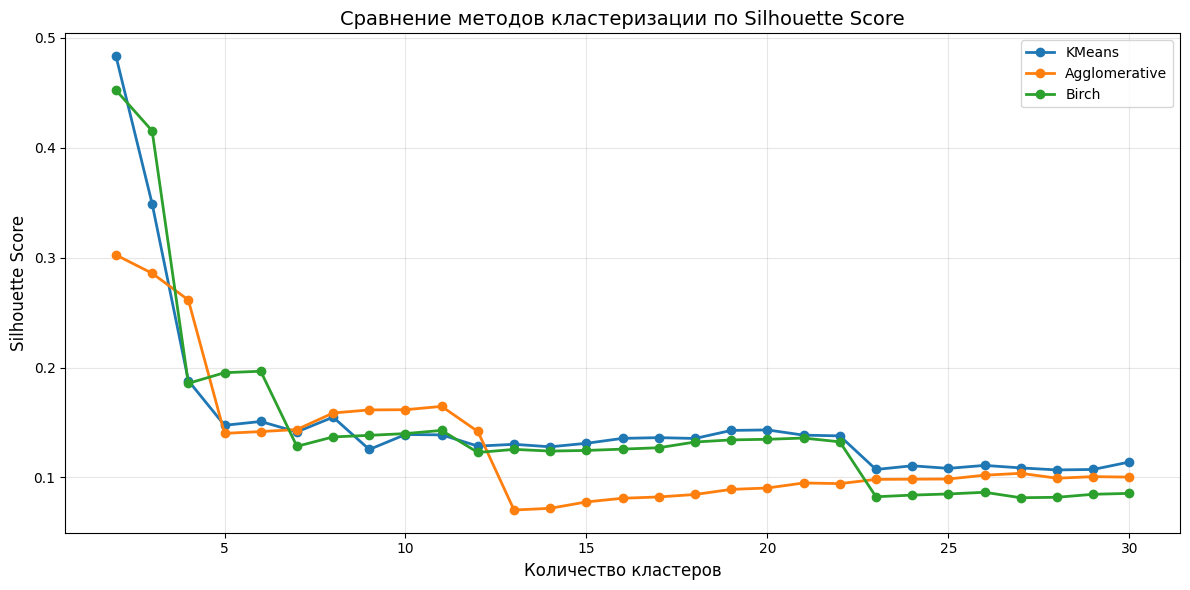

In [64]:
fig, ax = plt.subplots(figsize=(12, 6))

for method in results_df["method"].unique():
    method_data = results_df[results_df["method"] == method]
    ax.plot(method_data["n_clusters"], method_data["silhouette_score"], 
            marker='o', label=method, linewidth=2)

ax.set_xlabel("Количество кластеров", fontsize=12)
ax.set_ylabel("Silhouette Score", fontsize=12)
ax.set_title("Сравнение методов кластеризации по Silhouette Score", fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

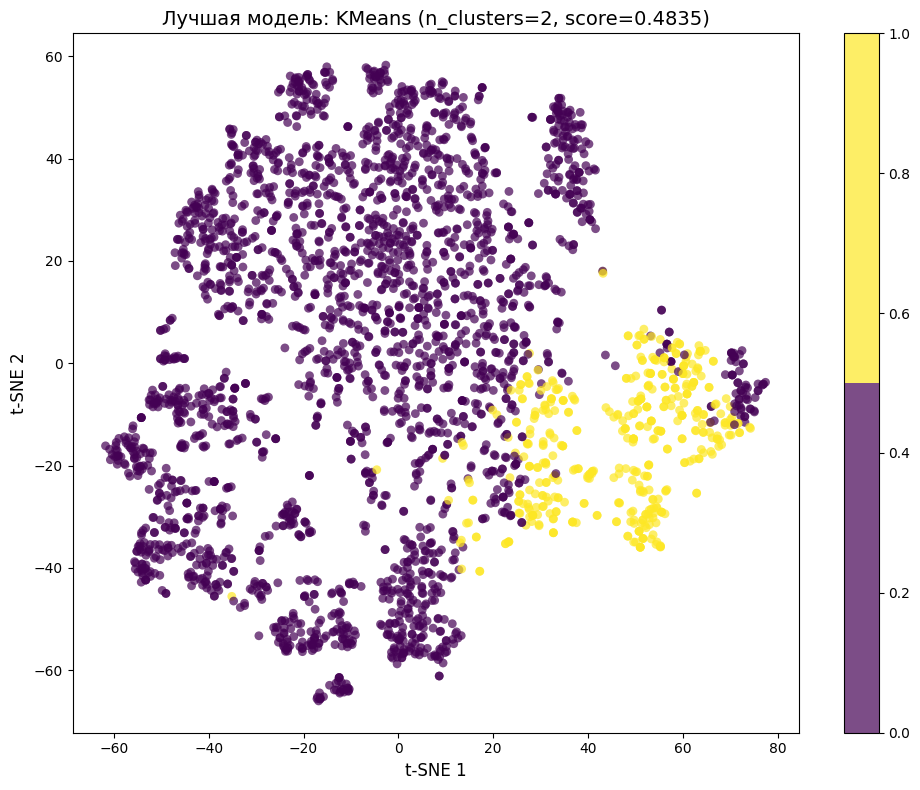

In [72]:
best_result = results_df.loc[results_df["silhouette_score"].idxmax()]
best_n_clusters = int(best_result['n_clusters'])
best_method = best_result['method']

if best_method == "KMeans":
    best_model = KMeans(n_clusters=best_n_clusters, random_state=RANDOM_SEED, n_init="auto")
elif best_method == "Agglomerative":
    best_model = AgglomerativeClustering(n_clusters=best_n_clusters, linkage="ward")
else:
    best_model = Birch(n_clusters=best_n_clusters)

best_labels = best_model.fit_predict(X_train_scaled)

tsne_best = TSNE(random_state=RANDOM_SEED)
X_tsne_best = tsne_best.fit_transform(X_train_scaled)

plt.figure(figsize=(10, 8))
sc = plt.scatter(X_tsne_best[:, 0], X_tsne_best[:, 1], c=best_labels,
                edgecolor='none', alpha=0.7, s=40,
                cmap=plt.get_cmap('viridis', best_n_clusters))
plt.colorbar(sc)
plt.title(f"Лучшая модель: {best_method} (n_clusters={best_n_clusters}, score={best_result['silhouette_score']:.4f})", 
          fontsize=14)
plt.xlabel("t-SNE 1", fontsize=12)
plt.ylabel("t-SNE 2", fontsize=12)
plt.tight_layout()
plt.show()

In [66]:
n_cluster_sizes = pd.Series(best_labels).value_counts().sort_index()
print("Размеры кластеров:")
print(n_cluster_sizes)

Размеры кластеров:
0    2658
1     455
Name: count, dtype: int64


**Выводы:**
- Лучший результат показал алгоритм KMeans с 2 кластерами (silhouette score = 0.48);
- Второй кластер содержит меньше 15% от всех данных;
- При количестве кластеров больше 2, silhouette score резко падает.

### HDBSCAN

In [67]:
hdbscan_model = HDBSCAN(min_cluster_size=10, min_samples=5)
hdbscan_labels = hdbscan_model.fit_predict(X_train_scaled)

n_clusters_hdbscan = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
n_noise = list(hdbscan_labels).count(-1)

if n_clusters_hdbscan > 1:
    non_noise_mask = hdbscan_labels != -1
    if non_noise_mask.sum() > 0:
        silhouette_hdbscan = silhouette_score(X_train_scaled[non_noise_mask], hdbscan_labels[non_noise_mask])
        print(f"\nSilhouette Score (без учета шума): {silhouette_hdbscan:.4f}")
else:
    print("\nSilhouette Score: не применим (недостаточно кластеров)")


Silhouette Score (без учета шума): 0.2360


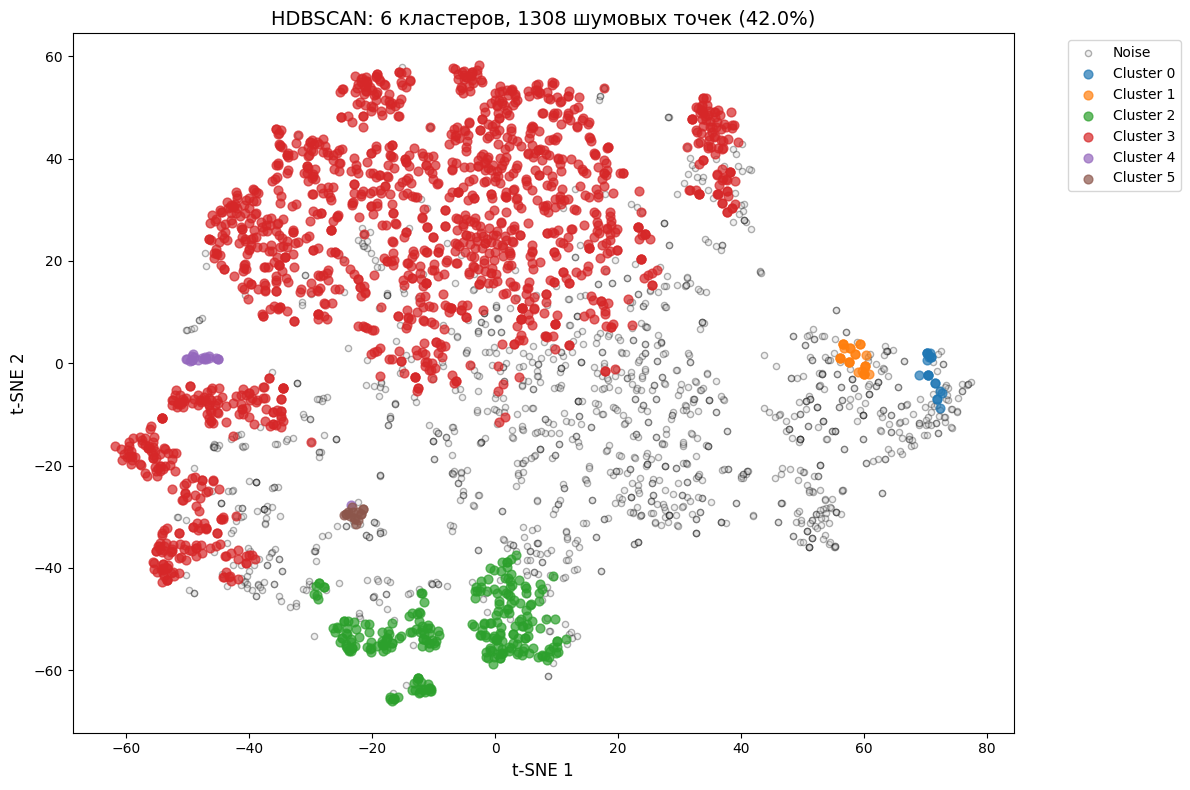

In [68]:
tsne_hdbscan = TSNE(random_state=RANDOM_SEED)
X_tsne_hdbscan = tsne_hdbscan.fit_transform(X_train_scaled)

plt.figure(figsize=(12, 8))

for cluster_id in sorted(set(hdbscan_labels)):
    mask = hdbscan_labels == cluster_id
    if cluster_id == -1:
        plt.scatter(X_tsne_hdbscan[mask, 0], X_tsne_hdbscan[mask, 1], 
                   c='lightgray', edgecolor='black', alpha=0.3, s=20, label='Noise')
    else:
        plt.scatter(X_tsne_hdbscan[mask, 0], X_tsne_hdbscan[mask, 1], 
                   alpha=0.7, s=40, label=f'Cluster {cluster_id}')

plt.xlabel("t-SNE 1", fontsize=12)
plt.ylabel("t-SNE 2", fontsize=12)
plt.title(f"HDBSCAN: {n_clusters_hdbscan} кластеров, {n_noise} шумовых точек ({n_noise / len(hdbscan_labels) * 100:.1f}%)", 
          fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Подберем оптимальные параметры для HDBSCAN с помощью Optuna. Целевая метрика учитывает как silhouette score, так и долю шума в данных. Также штрафуется разделение на слишком малое или слишком большое количество кластеров.

In [73]:
def objective_hdbscan(trial):
    params = {
        "min_cluster_size": trial.suggest_int("min_cluster_size", 5, 100),
        "min_samples": trial.suggest_int("min_samples", 1, 50),
        "cluster_selection_epsilon": trial.suggest_float("cluster_selection_epsilon", 0.0, 0.5),
        "alpha": trial.suggest_float("alpha", 0.5, 1.5),
    }
    model = HDBSCAN(**params)
    labels = model.fit_predict(X_train_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_ratio = n_noise / len(labels)

    if n_clusters < 3 or n_clusters > 30:
        return 1000.0
    
    if noise_ratio > 0.5:
        return 1000.0
    
    non_noise_mask = labels != -1
    if non_noise_mask.sum() < 10:
        return 1000.0
    
    try:
        sil_score = silhouette_score(X_train_scaled[non_noise_mask], labels[non_noise_mask])
    except:
        return 1000.0
    
    combined_score = -sil_score + 0.5 * noise_ratio
    return combined_score


study_hdbscan = optuna.create_study(direction="minimize")
study_hdbscan.optimize(objective_hdbscan, n_trials=150, show_progress_bar=True)

print(f"Лучший результат: {-study_hdbscan.best_value:.4f}")
print(f"Лучшие параметры: {study_hdbscan.best_params}")

Best trial: 64. Best value: -0.578439: 100%|██████████| 150/150 [00:36<00:00,  4.13it/s]

Лучший результат: 0.5784
Лучшие параметры: {'min_cluster_size': 7, 'min_samples': 31, 'cluster_selection_epsilon': 0.45400521474328465, 'alpha': 0.5679717361918143}



Silhouette Score (без учета шума): 0.0262


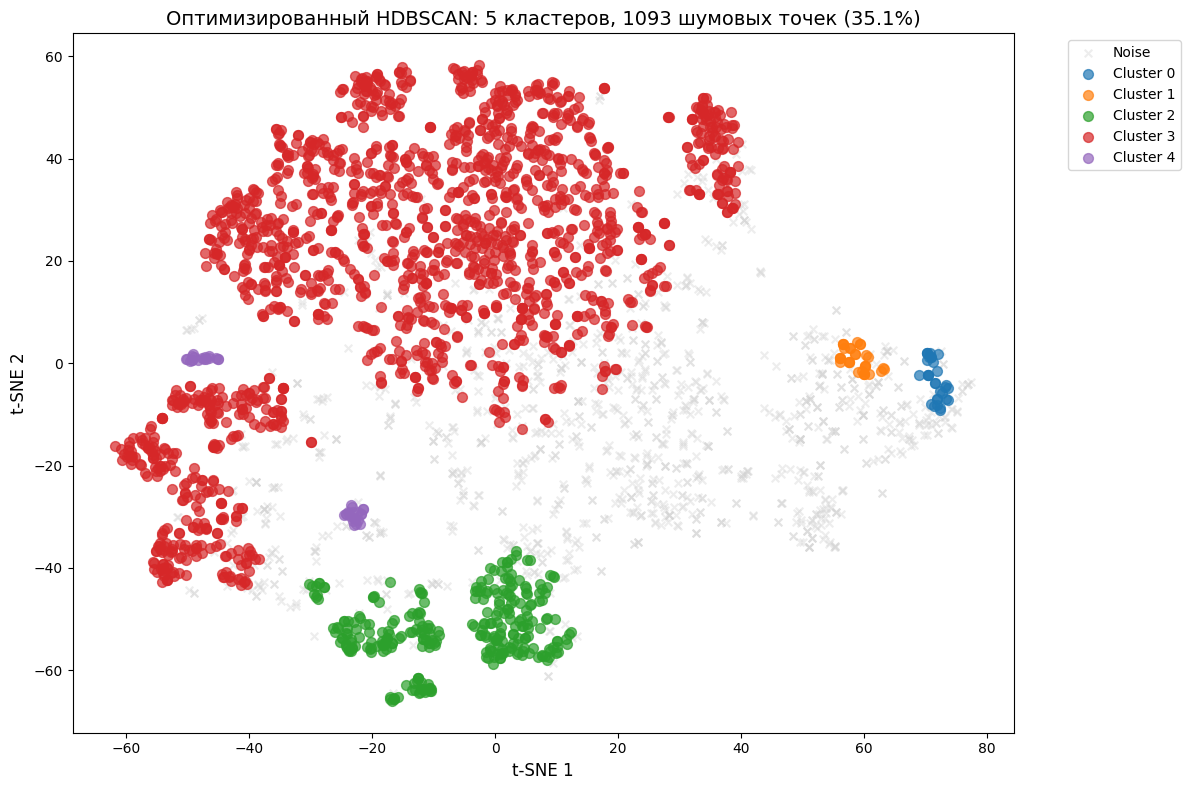

In [70]:
best_hdbscan = HDBSCAN(**study_hdbscan.best_params)
hdbscan_tuned_labels = best_hdbscan.fit_predict(X_train_scaled)

cluster_counts_tuned = pd.Series(hdbscan_tuned_labels).value_counts().sort_index()
n_clusters_tuned = len(set(hdbscan_tuned_labels)) - (1 if -1 in hdbscan_tuned_labels else 0)
n_noise_tuned = list(hdbscan_tuned_labels).count(-1)
non_noise_clusters = cluster_counts_tuned[cluster_counts_tuned.index != -1]

tsne_hdbscan_tuned = TSNE(random_state=RANDOM_SEED)
X_tsne_hdbscan_tuned = tsne_hdbscan_tuned.fit_transform(X_train_scaled)

silhouttte_tuned = silhouette_score(X_train_scaled[non_noise_clusters.index], hdbscan_tuned_labels[non_noise_clusters.index])
print(f"\nSilhouette Score (без учета шума): {silhouttte_tuned:.4f}")

plt.figure(figsize=(12, 8))

for cluster_id in sorted(set(hdbscan_tuned_labels)):
    mask = hdbscan_tuned_labels == cluster_id
    if cluster_id == -1:
        plt.scatter(X_tsne_hdbscan_tuned[mask, 0], X_tsne_hdbscan_tuned[mask, 1], 
                   c='lightgray', marker='x', alpha=0.4, s=30, label='Noise')
    else:
        plt.scatter(X_tsne_hdbscan_tuned[mask, 0], X_tsne_hdbscan_tuned[mask, 1], 
                   alpha=0.7, s=50, label=f'Cluster {cluster_id}')

plt.xlabel("t-SNE 1", fontsize=12)
plt.ylabel("t-SNE 2", fontsize=12)
plt.title(f"Оптимизированный HDBSCAN: {n_clusters_tuned} кластеров, "
          f"{n_noise_tuned} шумовых точек ({n_noise_tuned / len(hdbscan_tuned_labels) * 100:.1f}%)", 
          fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Выводы:**
- Применение HDBSCAN, как с дефолтными параметрами, так и с оптимизированными параметрами, не привело к улучшению качества кластеризации для создания фичи;
- Кластеры либо слишком большие, либо слишком маленькие, либо содержат слишком много шума, что делает их неинформативными для модели.

### Итоговая кластеризация

Оба вида кластеризации не показали хороших результатов. Тем не менее приоритизируя silhouette score и минимизацию шума, можно выделить KMeans с 2 кластерами как наиболее перспективный вариант для создания фичи.

In [74]:
best_clustering = KMeans(n_clusters=2, random_state=RANDOM_SEED, n_init="auto")
final_labels = best_clustering.fit_predict(X_train_scaled)

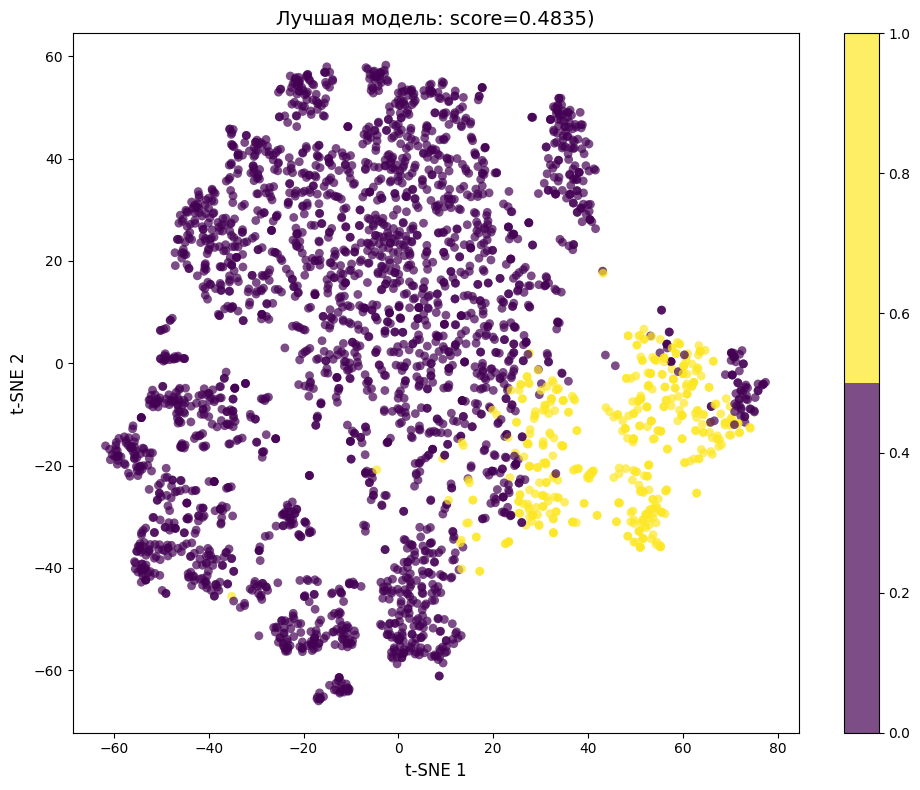

In [75]:
score = silhouette_score(X_train_scaled, final_labels)

plt.figure(figsize=(10, 8))
sc = plt.scatter(X_tsne_best[:, 0], X_tsne_best[:, 1], c=final_labels,
                edgecolor='none', alpha=0.7, s=40,
                cmap=plt.get_cmap('viridis', 2))
plt.colorbar(sc)
plt.title(f"Лучшая модель: score={score:.4f})", 
          fontsize=14)
plt.xlabel("t-SNE 1", fontsize=12)
plt.ylabel("t-SNE 2", fontsize=12)
plt.tight_layout()
plt.show()

In [76]:
X_train_with_clusters = X_train_encoded.copy()
X_train_with_clusters["cluster"] = final_labels

X_val_with_clusters = X_val_encoded.copy()
X_val_with_clusters["cluster"] = best_clustering.predict(X_val_scaled)

X_test_with_clusters = X_test_encoded.copy()
X_test_with_clusters["cluster"] = best_clustering.predict(X_test_scaled)

encoder = TargetEncoder(smoothing=0.1)
X_train_encoded_cluster = encoder.fit_transform(X_train_with_clusters, y_train, columns=["cluster"])
X_val_encoded_cluster = encoder.transform(X_val_with_clusters)
X_test_encoded_cluster = encoder.transform(X_test_with_clusters)

## Случайный лес с фичей кластеров

Возьмем лучшую модель - случайный лес, и добавим в нее фичу кластеров, полученную с помощью KMeans. Также проведем оптимизацию гиперпараметров для новой модели.

In [77]:
def objective_rf_cluster(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 2, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 50),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
        "max_features": trial.suggest_float("max_features", 0.3, 1.0),
        "random_state": RANDOM_SEED,
        "n_jobs": -1,
    }
    model = RandomForestRegressor(**params)
    model.fit(X_train_encoded_cluster, y_train)
    y_pred = model.predict(X_val_encoded_cluster)
    return root_mean_squared_error(y_val, y_pred)


study_rf_cluster = optuna.create_study(direction="minimize")
study_rf_cluster.optimize(objective_rf_cluster, n_trials=100, show_progress_bar=True)

print(f"Best RMSE: {study_rf_cluster.best_value:.4f}")
print(f"Best params: {study_rf_cluster.best_params}")

Best trial: 52. Best value: 0.0468075: 100%|██████████| 100/100 [00:44<00:00,  2.26it/s]

Best RMSE: 0.0468
Best params: {'n_estimators': 384, 'max_depth': 28, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 0.41865928558138654}


In [78]:
rf_cluster_tuned = RandomForestRegressor(**study_rf_cluster.best_params, random_state=RANDOM_SEED, n_jobs=-1)
rf_cluster_tuned.fit(X_train_encoded_cluster, y_train)

y_pred_rf_cluster_tuned = rf_cluster_tuned.predict(X_test_encoded_cluster)
test_performance(y_test, y_pred_rf_cluster_tuned)


Test Performance:
   RMSE: 0.0433
   MAE:  0.0343
   R²:   0.755


**Результаты:**
- RMSE: 0.0433
- MAE: 0.0343
- R²: 0.755

**Лучшие параметры:**
- n_estimators: 384
- max_depth: 28
- min_samples_split: 4
- min_samples_leaf: 2
- max_features: 0.41

**Вывод:** Случайный лес с кластеризацией не дал прироста в качестве по сравнению с лучшим результатом без кластеризации (RMSE = 0.0432). Это может свидетельствовать о том, что фича кластеров не добавляет значимой информации для модели.

## Интерпретация результатов лучшей модели

In [89]:
best_model = RandomForestRegressor(**study_rf.best_params, random_state=RANDOM_SEED, n_jobs=-1)
best_model.fit(X_train_encoded, y_train)

,n_estimators,357
,criterion,'squared_error'
,max_depth,26
,min_samples_split,6
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,0.4117617376684628
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [90]:
sample_indices = np.random.choice(X_test_encoded.shape[0], size=min(1000, X_test_encoded.shape[0]), replace=False)
X_sample = X_test_encoded.iloc[sample_indices]

In [91]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample.values)

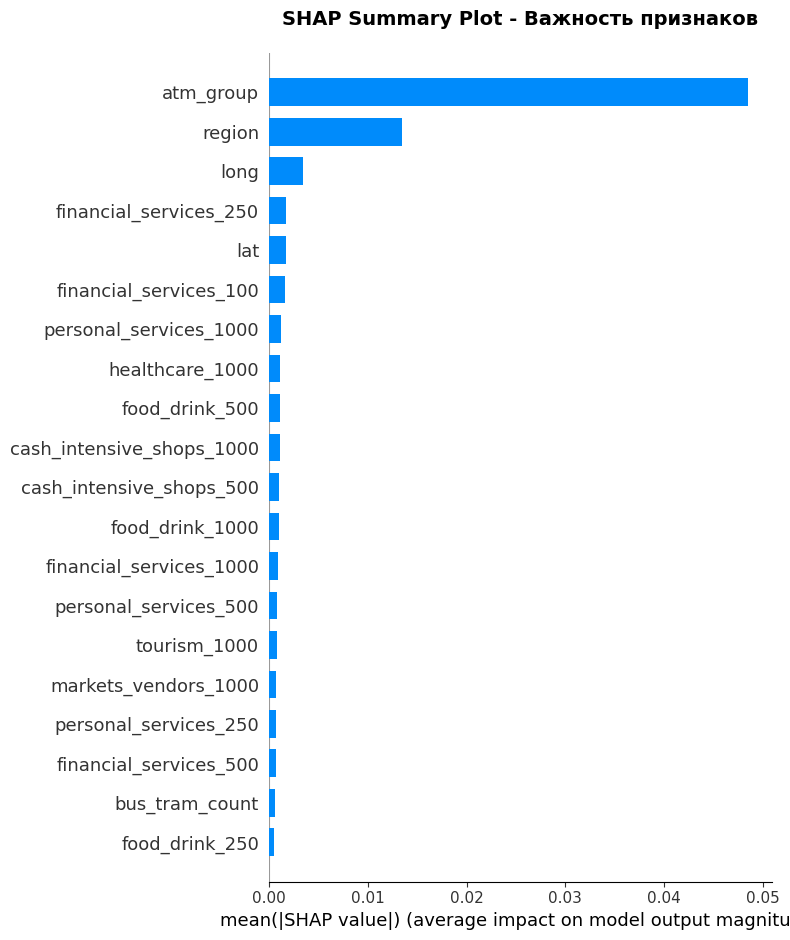

In [97]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title('SHAP Summary Plot - Важность признаков', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

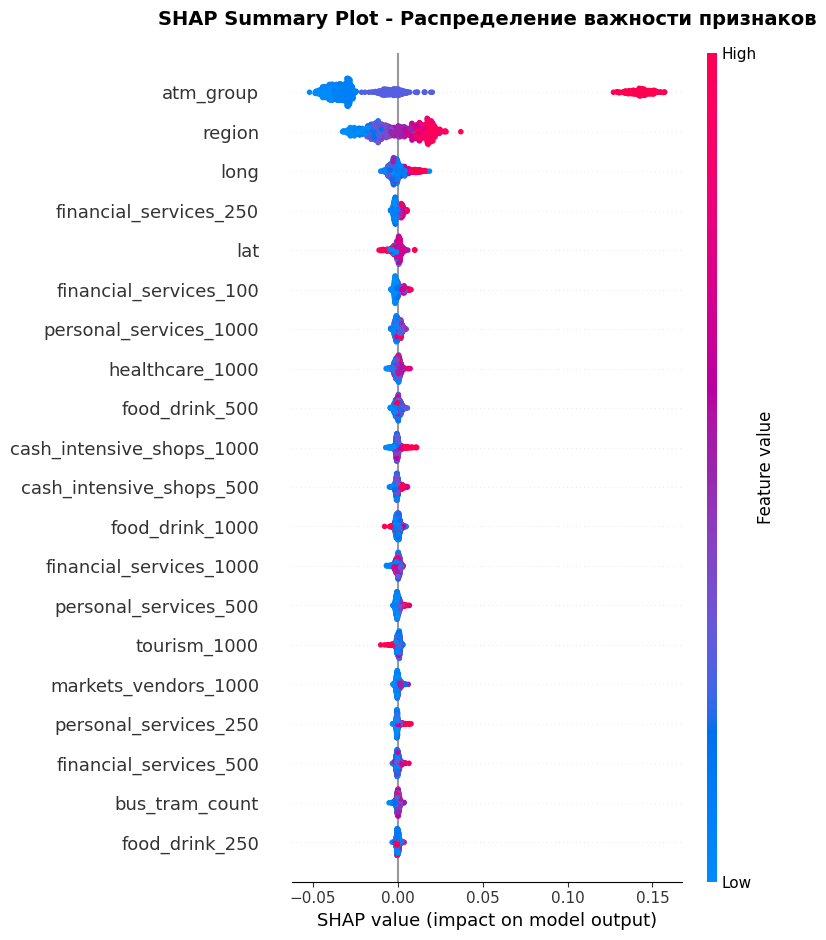

In [96]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, plot_type="dot", show=False)
plt.title('SHAP Summary Plot - Распределение важности признаков', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

**Выводы:**
- Наиболее важными признаками для модели являются: `atm_group`, `region`, `long`;
- Анализируя распределение SHAP-значений для этих признаков, можно заметить, что определенные значения `atm_group` и `region` могут значительно увеличивать или уменьшать предсказанное значение популярности, в зависимости от их конкретного значения;
- Остальные признаки внесят небольшой вклад в предсказание, имея скорее ситуативный характер.
- Важность признаков совпадает с результатами, полученными при исслодовании линейных моделей.


## Выводы

| Модель | RMSE | MAE | R² | Время обучения (секунды) |
|--------|------|-----|-----|----------------|
| Decision Tree | 0.0462 | 0.0372 | 0.721 | 0.04 |
| Random Forest | 0.0432 | 0.0343 | 0.755 | 0.20 |
| CatBoost | 0.0438 | 0.0346 | 0.749 | 1.57 |
| LightGBM | 0.0437 | 0.0348 | 0.751 | 0.18 |
| Random Forest + Clusters | 0.0433 | 0.0343 | 0.755 | 0.04 |

(Время обучения исследуется в файле `model_speedtest.py`)

**Лучшая модель:** Random Forest (RMSE = 0.0432)

- Случайный лес показал лучший результат среди всех протестированных моделей, что можно объяснить его наибольшему сопротивлению к переобучению;
- Кластеризация не добавила значимой информации для улучшения предсказаний;
- Наиболее важные признаки: `atm_group`, `region`, `long`